## Dropout
- This is the  technique which is used to decrease overfitting just like we had the Random Forest Similarly we have in which in each epoch a new model is trained due ti which the overfitting decreases 

- There is a issue that since the weight was not updated so we will not have the value of weight so if we have selected the p =0.25 then the probability of that node staying in that artitecture is 0.75 so during the prediction the weight will be 0.75 of the weight

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from keras import Sequential
from tensorflow.keras.layers import Dropout
import pandas as pd

In [3]:
from tensorflow.keras.optimizers import Adam

In [4]:
df = pd.read_csv("/run/media/darshchouhan/New Volume/DL-Algorithm/hyperparameters/Social_Network_Ads.csv")

In [13]:
import numpy as np
X_train=np.linspace(-1,1,20)
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [14]:
X_test = np.linspace(-1, 1, 20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

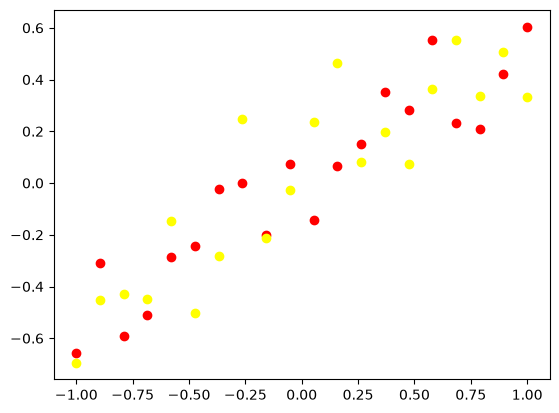

In [15]:
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train,c='red',label='Train')
plt.scatter(X_test,y_test,c='yellow',label = 'test')

In [38]:
model1 = Sequential()
model1.add(Dense(256,input_dim=1,activation='relu'))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(128,activation='relu'))
# the output is of one dimention=
model1.add(Dense(1,activation='linear'))
model1.compile(loss='mse',optimizer='adam',metrics=['mse'])
history = model1.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=True)

Epoch 1/500


/run/media/darshchouhan/New Volume/DL-Algorithm/venv/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1171 - mse: 0.1171 - val_loss: 0.1045 - val_mse: 0.1045
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0927 - mse: 0.0927 - val_loss: 0.0858 - val_mse: 0.0858
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0743 - mse: 0.0743 - val_loss: 0.0698 - val_mse: 0.0698
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0589 - mse: 0.0589 - val_loss: 0.0556 - val_mse: 0.0556
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0454 - mse: 0.0454 - val_loss: 0.0439 - val_mse: 0.0439
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0344 - mse: 0.0344 - val_loss: 0.0356 - val_mse: 0.0356
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0269 - mse: 0.0269 - val_loss: 0.0315 - val_mse: 0.0315
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0234 - mse: 0.0234 - val_loss: 0.0304 - val_mse: 0.0304
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0229 - mse: 0.0229 -

In [43]:
model1.compile()

<Axes: >

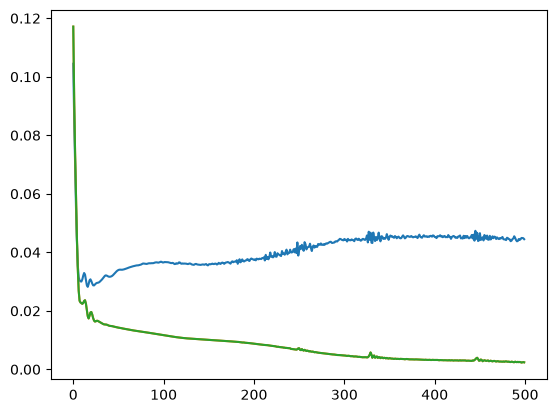

In [39]:
import seaborn as sns
sns.lineplot(history.history['val_mse'])
sns.lineplot(history.history['loss'])
sns.lineplot(history.history['mse'])

In [52]:
y_pred1 = model1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


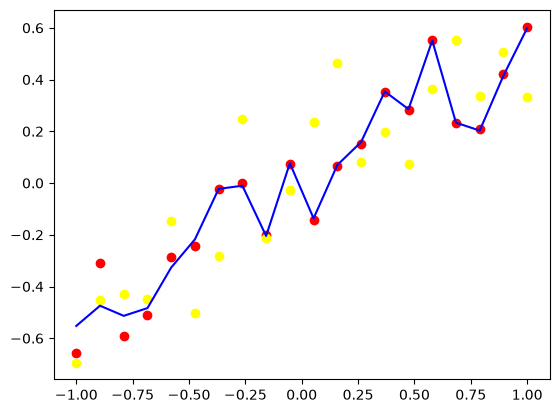

In [53]:
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train,c='red',label='Train')
plt.scatter(X_test,y_test,c='yellow',label = 'test')
plt.plot(X_test,y_pred1,color = 'blue')

## It is clear that the overfitting is happening 

# Adding Droupout into the layers

In [46]:
model2 = Sequential()
model2.add(Dense(256,input_dim=1,activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(128,activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(128,activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(128,activation='relu'))
# the output is of one dimention=
model2.add(Dropout(0.2))
model2.add(Dense(1,activation='linear'))
model2.compile(loss='mse',optimizer='adam',metrics=['mse'])
history = model2.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=True)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1265 - mse: 0.1265 - val_loss: 0.1270 - val_mse: 0.1270
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1182 - mse: 0.1182 - val_loss: 0.1100 - val_mse: 0.1100
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.1021 - mse: 0.1021 - val_loss: 0.0935 - val_mse: 0.0935
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0831 - mse: 0.0831 - val_loss: 0.0784 - val_mse: 0.0784
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0678 - mse: 0.0678 - val_loss: 0.0646 - val_mse: 0.0646
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0611 - mse: 0.0611 - val_loss: 0.0517 - val_mse: 0.0517
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0494 - mse: 0.0494 - val_loss: 0.0408 - val_mse: 0.0408
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0385 - mse: 0.0385 - val_loss: 0.0332 - val_mse: 0.0332
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0312 - mse: 0.

<Axes: >

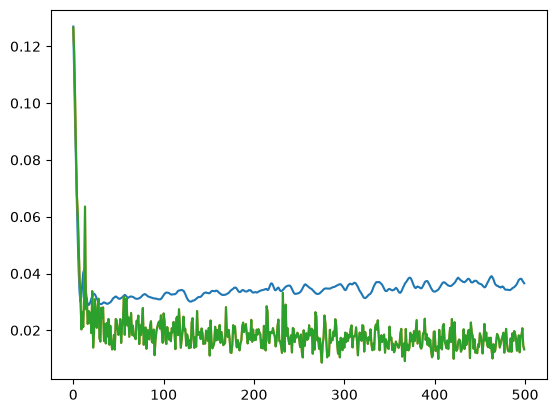

In [58]:
import seaborn as sns
sns.lineplot(history.history['val_mse'])
sns.lineplot(history.history['loss'])
sns.lineplot(history.history['mse'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


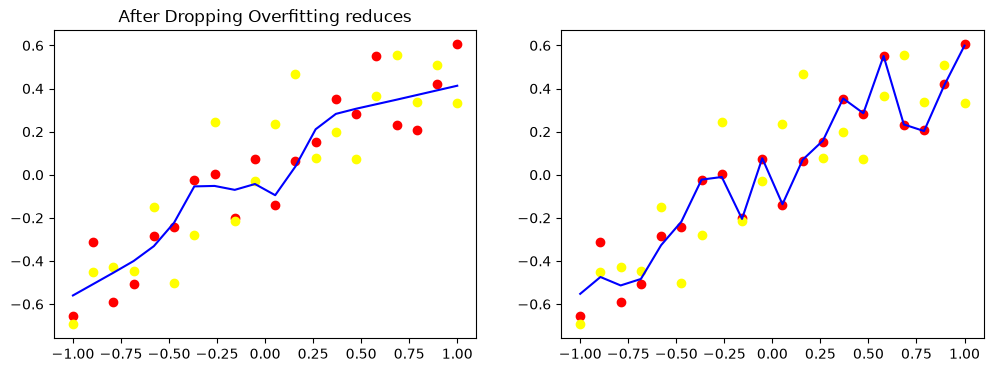

In [57]:
y_pred2 = model2.predict(X_test)
fig,axs = plt.subplots(1,2,figsize=(12,4))

import matplotlib.pyplot as plt
axs[0].scatter(X_train,y_train,c='red',label='Train')
axs[0].scatter(X_test,y_test,c='yellow',label = 'test')
axs[0].set_title("After Dropping Overfitting reduces")
axs[0].plot(X_test,y_pred2,color = 'blue')
axs[1].scatter(X_train,y_train,c='red',label='Train')
axs[1].scatter(X_test,y_test,c='yellow',label = 'test')
axs[1].plot(X_test,y_pred1,color = 'blue')
